# Full-history training style, muscle volume, frequency, and press progression

**Question:** Does the current split/program fit the observed training response,
or should muscle-group frequency and volume change?

## Measurement contract

- Source: live read-only BenchTracker/Postgres corpus, not the slightly stale local `.wld` export.
- Grain: one source set. A **recorded set** has positive reps. The source does not identify warm-ups,
  failure proximity, or reliably populated RPE/RIR, so this analysis does **not** call these “hard sets.”
- Direct volume: sets logged under the app's exercise category.
- Estimated stimulus-equivalent sets: 1.0 for a primary group plus 0.5 for common compound secondaries.
  This is an auditable planning heuristic, not physiology measured in a lab.
- Frequency: distinct workout sessions touching a category, not workout names.
- Press progression: like-for-like session-best estimated 1RM; variants are not mixed.
- “Current” = rolling 12 weeks ending at the latest recorded workout; compared with the preceding 12 weeks.

In [1]:
from pathlib import Path
import io
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parent
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from training_program_analysis import (
    add_press_family,
    estimate_muscle_stimulus,
    prepare_set_records,
    summarize_category_window,
)
from chart_style import (
    CATEGORICAL_COLORS,
    NOTEBOOK_AXES,
    PALETTE,
    add_footer,
    add_header,
    chart_canvas,
    notebook_frame,
    style_axes,
    style_legend,
)

OUTPUTS = REPO / "outputs"
OUTPUTS.mkdir(exist_ok=True)
Q_SH = Path.home() / ".agents/skills/weightlifting/scripts/q.sh"


In [2]:
QUERY = r"""
SELECT
  w.id AS workout_id,
  w.uuid AS workout_uuid,
  w.date,
  w.name AS workout_name,
  w.duration_seconds,
  e.id AS exercise_id,
  e.exercise_order,
  e.name,
  e.category,
  e.style,
  COALESCE(e.iteration, '') AS iteration,
  s.id AS set_id,
  s.set_order,
  s.reps,
  s.weight,
  s.volume,
  s.one_rm
FROM wl_workouts w
JOIN wl_exercises e ON e.workout_id = w.id
JOIN wl_sets s ON s.exercise_id = e.id
ORDER BY w.date, w.id, e.exercise_order, s.set_order;
"""
proc = subprocess.run([str(Q_SH), QUERY], check=True, capture_output=True, text=True)
csv_lines = [line for line in proc.stdout.splitlines() if line.strip() and line.strip() != "SET"]
raw = pd.read_csv(io.StringIO("\n".join(csv_lines)))
sets = add_press_family(prepare_set_records(raw))
recorded = sets[sets["is_recorded_set"] & sets["date"].notna()].copy()

latest = recorded["date"].max()
first = recorded["date"].min()
current_start = latest - pd.Timedelta(days=12 * 7 - 1)
prior_end = current_start - pd.Timedelta(days=1)
prior_start = prior_end - pd.Timedelta(days=12 * 7 - 1)

coverage = pd.DataFrame({
    "metric": ["First workout", "Latest workout", "Workouts", "Training days", "Exercise instances", "All sets", "Positive-rep recorded sets"],
    "value": [first.date(), latest.date(), raw["workout_id"].nunique(), recorded["date"].nunique(),
              raw["exercise_id"].nunique(), len(raw), len(recorded)],
})
coverage


,metric,value
0,First workout,2017-08-10
1,Latest workout,2026-08-18
2,Workouts,2308
3,Training days,2304
4,Exercise instances,10851
5,All sets,47989
6,Positive-rep recorded sets,47528


## 1. Training style over time

Annual counts reveal the macro style; rolling windows reveal the actual current program.
Workout IDs—not names or dates—are used as session identifiers.

In [3]:
annual = (
    recorded.assign(year=recorded["date"].dt.year)
    .groupby("year")
    .agg(workouts=("workout_id", "nunique"), training_days=("date", "nunique"),
         recorded_sets=("set_id", "nunique"), tonnage=("volume", "sum"))
    .reset_index()
)
annual["sets_per_workout"] = annual["recorded_sets"] / annual["workouts"]
annual


,year,workouts,training_days,recorded_sets,tonnage,sets_per_workout
0,2017,109,107,2226,1946379.0,20.422018
1,2018,234,234,4301,4342460.0,18.380342
2,2019,231,231,4217,4102573.0,18.255411
3,2020,243,243,4194,4134236.0,17.259259
4,2021,206,205,3791,4028343.0,18.402913
5,2022,274,274,5689,6717844.0,20.762774
6,2023,304,304,6931,10900572.0,22.799342
7,2024,256,256,6264,8262275.0,24.468750
8,2025,273,273,6266,7716292.0,22.952381
9,2026,178,177,3649,4693899.0,20.500000


In [4]:
def window_summary(frame, start, end, label):
    window = frame[frame["date"].between(start, end)]
    workouts = window["workout_id"].nunique()
    days = window["date"].nunique()
    durations = window[["workout_id", "duration_seconds"]].drop_duplicates()["duration_seconds"] / 60
    return {
        "period": label, "start": start.date(), "end": end.date(), "workouts": workouts,
        "workouts_per_week": workouts / 12, "training_days_per_week": days / 12,
        "recorded_sets_per_week": len(window) / 12,
        "sets_per_workout": len(window) / workouts if workouts else np.nan,
        "median_duration_min": durations.median(),
    }

period_summary = pd.DataFrame([
    window_summary(recorded, prior_start, prior_end, "Prior 12 weeks"),
    window_summary(recorded, current_start, latest, "Current 12 weeks"),
])
period_summary


,period,start,end,workouts,workouts_per_week,training_days_per_week,recorded_sets_per_week,sets_per_workout,median_duration_min
0,Prior 12 weeks,2026-03-04,2026-05-26,63,5.250000,5.25,100.333333,19.111111,49.366667
1,Current 12 weeks,2026-05-27,2026-08-18,67,5.583333,5.50,110.000000,19.701493,49.950000


In [5]:
current_categories = summarize_category_window(
    recorded, start=current_start, end=latest, window_weeks=12
).assign(period="Current 12 weeks")
prior_categories = summarize_category_window(
    recorded, start=prior_start, end=prior_end, window_weeks=12
).assign(period="Prior 12 weeks")
category_compare = pd.concat([prior_categories, current_categories], ignore_index=True)
category_compare.to_csv(OUTPUTS / "training-category-current-vs-prior.csv", index=False)
category_compare


,category,direct_sets,sessions,sets_per_week,sessions_per_week,tonnage_per_week,period
0,Shoulders,208,34,17.333333,2.833333,12420.333333,Prior 12 weeks
1,Legs,207,19,17.250000,1.583333,38064.916667,Prior 12 weeks
2,Biceps,194,30,16.166667,2.500000,10665.000000,Prior 12 weeks
3,Back,179,24,14.916667,2.000000,14669.250000,Prior 12 weeks
4,Chest,161,26,13.416667,2.166667,27127.916667,Prior 12 weeks
5,Abs / Core,150,16,12.500000,1.333333,12350.000000,Prior 12 weeks
6,Triceps,105,17,8.750000,1.416667,17181.083333,Prior 12 weeks
7,Shoulders,315,47,26.250000,3.916667,19073.500000,Current 12 weeks
8,Biceps,260,45,21.666667,3.750000,12673.416667,Current 12 weeks
9,Legs,187,20,15.583333,1.666667,32358.833333,Current 12 weeks


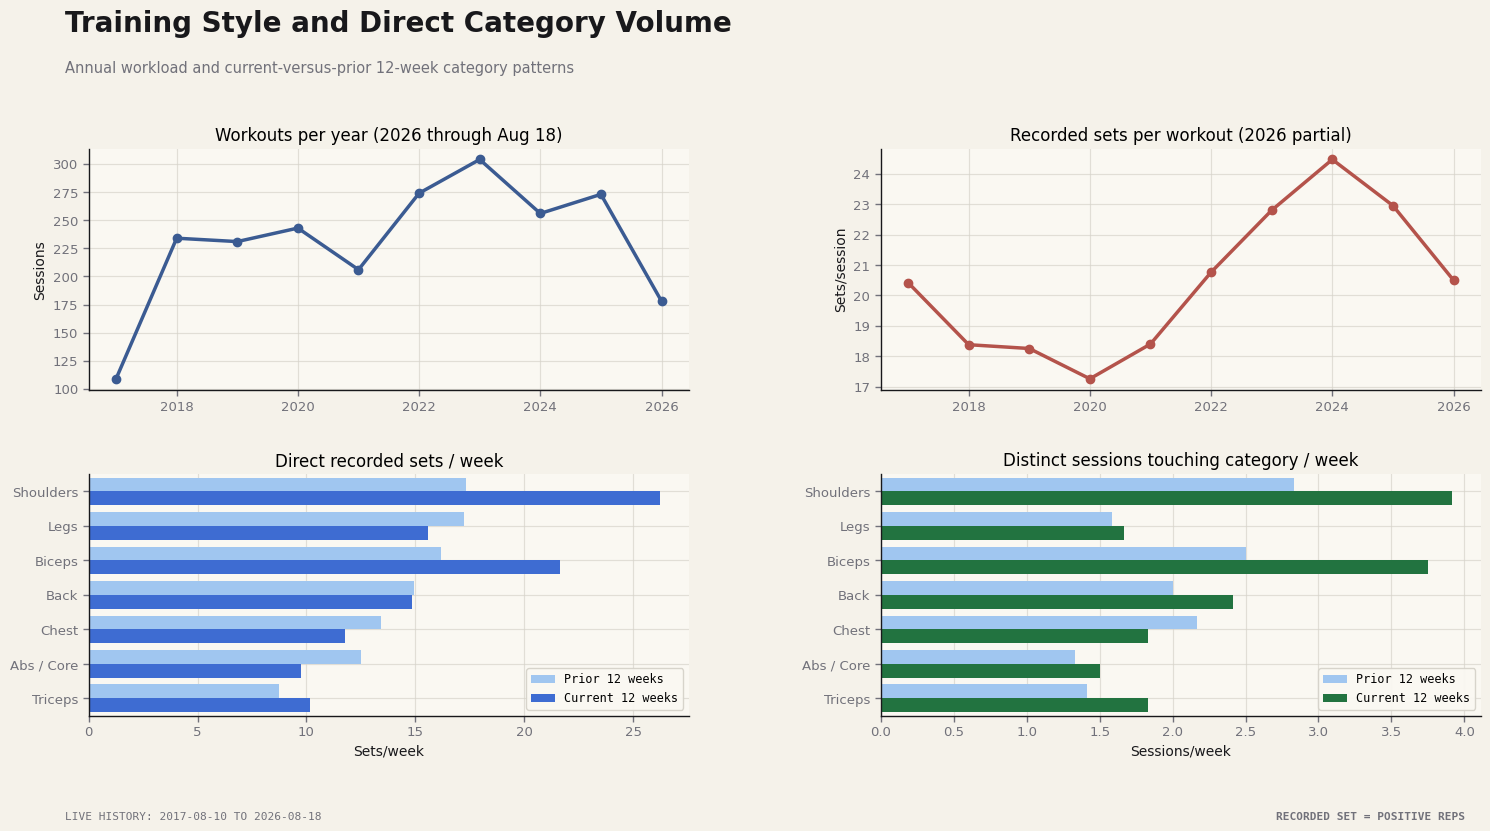

In [6]:
frame = notebook_frame((16, 9))
with chart_canvas(frame) as (fig, seed_ax):
    fig.delaxes(seed_ax)
    axes = fig.subplots(2, 2)
    fig.subplots_adjust(wspace=0.32, hspace=0.35)
    for ax in axes.flat:
        ax.set_facecolor(PALETTE.panel)

    add_header(
        fig,
        frame,
        "Training Style and Direct Category Volume",
        "Annual workload and current-versus-prior 12-week category patterns",
        (),
    )
    axes[0, 0].plot(
        annual["year"], annual["workouts"], marker="o", lw=2.5,
        color=CATEGORICAL_COLORS[0],
    )
    axes[0, 0].set(
        title=f"Workouts per year ({latest.year} through {latest:%b %d})",
        xlabel="",
        ylabel="Sessions",
    )
    axes[0, 1].plot(
        annual["year"], annual["sets_per_workout"], marker="o", lw=2.5,
        color=CATEGORICAL_COLORS[1],
    )
    axes[0, 1].set(
        title=f"Recorded sets per workout ({latest.year} partial)",
        xlabel="",
        ylabel="Sets/session",
    )
    sns.barplot(
        data=category_compare, y="category", x="sets_per_week", hue="period",
        ax=axes[1, 0], palette=[PALETTE.checkpoint, PALETTE.frontier],
    )
    axes[1, 0].set(
        title="Direct recorded sets / week", xlabel="Sets/week", ylabel=""
    )
    sns.barplot(
        data=category_compare, y="category", x="sessions_per_week", hue="period",
        ax=axes[1, 1], palette=[PALETTE.checkpoint, PALETTE.positive],
    )
    axes[1, 1].set(
        title="Distinct sessions touching category / week",
        xlabel="Sessions/week",
        ylabel="",
    )
    for ax in axes.flat:
        style_axes(ax, NOTEBOOK_AXES)
    for ax in axes[1]:
        style_legend(ax, loc="lower right")
    add_footer(
        fig,
        frame,
        f"LIVE HISTORY: {first.date()} TO {latest.date()}",
        "RECORDED SET = POSITIVE REPS",
    )
    fig.savefig(
        OUTPUTS / "training-style-and-volume.png",
        dpi=180,
        facecolor=fig.get_facecolor(),
    )
    plt.show()


## 2. Estimated muscle stimulus and frequency

This supplements—never replaces—the direct-category table. Compound coefficients are
intentionally simple and visible in `training_program_analysis.py`.

In [7]:
def expand_stimulus(frame):
    rows = []
    for row in frame.itertuples(index=False):
        for muscle, coefficient in estimate_muscle_stimulus(row.name, row.iteration, row.category).items():
            rows.append({"set_id": row.set_id, "workout_id": row.workout_id, "date": row.date,
                         "week_of": row.week_of, "muscle": muscle, "stimulus_sets": coefficient})
    return pd.DataFrame(rows)

current = recorded[recorded["date"].between(current_start, latest)].copy()
stimulus = expand_stimulus(current)
stimulus_summary = (
    stimulus.groupby("muscle")
    .agg(stimulus_sets=("stimulus_sets", "sum"), sessions=("workout_id", "nunique"))
    .assign(stimulus_sets_per_week=lambda x: x["stimulus_sets"] / 12,
            sessions_per_week=lambda x: x["sessions"] / 12)
    .sort_values("stimulus_sets_per_week", ascending=False).reset_index()
)
stimulus_summary.to_csv(OUTPUTS / "estimated-muscle-stimulus-current-12w.csv", index=False)
stimulus_summary


,muscle,stimulus_sets,sessions,stimulus_sets_per_week,sessions_per_week
0,Shoulders,368.5,54,30.708333,4.500000
1,Biceps,327.5,55,27.291667,4.583333
2,Triceps,221.0,44,18.416667,3.666667
3,Back,203.0,38,16.916667,3.166667
4,Chest,141.0,22,11.750000,1.833333
5,Abs / Core,117.0,18,9.750000,1.500000
6,Quads,78.0,12,6.500000,1.000000
7,Glutes,72.5,18,6.041667,1.500000
8,Hamstrings,63.0,10,5.250000,0.833333
9,Adductors,24.0,6,2.000000,0.500000


In [8]:
frequency_start = latest - pd.Timedelta(days=26 * 7 - 1)
category_days = (
    recorded[recorded["date"].between(frequency_start, latest)]
    [["category", "date", "workout_id"]].drop_duplicates().sort_values(["category", "date"])
)
gap_rows = []
for category, group in category_days.groupby("category"):
    days = pd.Series(sorted(group["date"].unique()))
    gaps = days.diff().dt.days.dropna()
    gap_rows.append({"category": category, "sessions": group["workout_id"].nunique(),
                     "sessions_per_week": group["workout_id"].nunique() / 26,
                     "median_days_between_hits": gaps.median(), "p90_days_between_hits": gaps.quantile(.9),
                     "longest_gap_days": gaps.max()})
frequency = pd.DataFrame(gap_rows).sort_values("sessions_per_week", ascending=False)
frequency.to_csv(OUTPUTS / "category-frequency-current-26w.csv", index=False)
frequency


,category,sessions,sessions_per_week,median_days_between_hits,p90_days_between_hits,longest_gap_days
5,Shoulders,89,3.423077,2.0,3.0,9.0
2,Biceps,81,3.115385,2.0,4.0,9.0
1,Back,59,2.269231,3.0,5.0,11.0
3,Chest,53,2.038462,3.0,5.0,12.0
4,Legs,43,1.653846,4.0,7.9,10.0
6,Triceps,42,1.615385,4.0,6.0,15.0
0,Abs / Core,38,1.461538,4.0,8.0,14.0


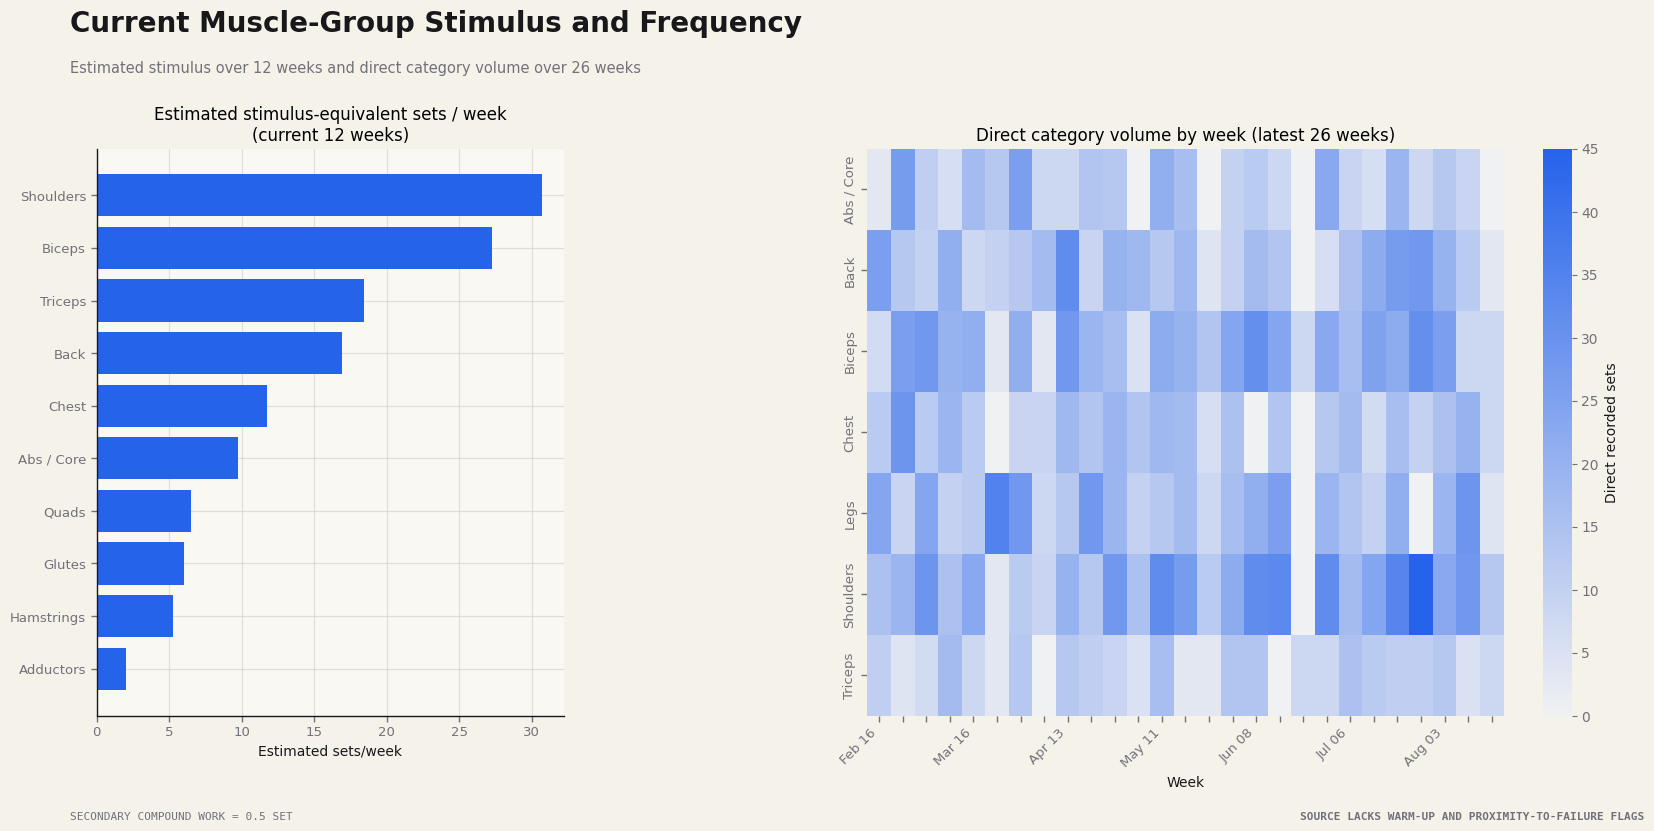

In [9]:
recent26 = recorded[recorded["date"].between(frequency_start, latest)].copy()
weekly_heat = recent26.groupby(["week_of", "category"])["set_id"].nunique().unstack(fill_value=0).sort_index()
frame = notebook_frame((18, 9))
with chart_canvas(frame) as (fig, seed_ax):
    fig.delaxes(seed_ax)
    axes = fig.subplots(1, 2, gridspec_kw={"width_ratios": [1, 1.7]})
    fig.subplots_adjust(wspace=0.48)
    for ax in axes:
        ax.set_facecolor(PALETTE.panel)

    add_header(
        fig,
        frame,
        "Current Muscle-Group Stimulus and Frequency",
        "Estimated stimulus over 12 weeks and direct category volume over 26 weeks",
        (),
    )
    ordered_stimulus = stimulus_summary.sort_values("stimulus_sets_per_week")
    axes[0].barh(
        ordered_stimulus["muscle"],
        ordered_stimulus["stimulus_sets_per_week"],
        color=PALETTE.frontier,
    )
    axes[0].set(
        title="Estimated stimulus-equivalent sets / week\n(current 12 weeks)",
        xlabel="Estimated sets/week",
        ylabel="",
    )
    sns.heatmap(
        weekly_heat.T,
        cmap=sns.light_palette(PALETTE.frontier, as_cmap=True),
        ax=axes[1],
        cbar_kws={"label": "Direct recorded sets"},
    )
    axes[1].set(
        title="Direct category volume by week (latest 26 weeks)",
        xlabel="Week",
        ylabel="",
    )
    axes[1].tick_params(axis="y", labelsize=12, pad=4)
    labels = [
        date.strftime("%b %d") if index % 4 == 0 else ""
        for index, date in enumerate(weekly_heat.index)
    ]
    axes[1].set_xticks(np.arange(len(labels)) + 0.5)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")
    for ax in axes:
        style_axes(ax, NOTEBOOK_AXES)
    add_footer(
        fig,
        frame,
        "SECONDARY COMPOUND WORK = 0.5 SET",
        "SOURCE LACKS WARM-UP AND PROXIMITY-TO-FAILURE FLAGS",
    )
    fig.savefig(
        OUTPUTS / "muscle-stimulus-and-frequency.png",
        dpi=180,
        facecolor=fig.get_facecolor(),
    )
    plt.show()


## 3. What the current split actually looks like

Generic workout names cannot identify a split. Each recent workout is instead described
by categories touched and its dominant category by recorded-set count.

In [10]:
session_category = current.groupby(["workout_id", "date", "category"])["set_id"].nunique().rename("sets").reset_index()
session_wide = session_category.pivot_table(index=["workout_id", "date"], columns="category", values="sets", fill_value=0).reset_index()
category_columns = [c for c in session_wide.columns if c not in ("workout_id", "date")]
session_wide["total_sets"] = session_wide[category_columns].sum(axis=1)
session_wide["dominant_category"] = session_wide[category_columns].idxmax(axis=1)
session_wide["categories_touched"] = (session_wide[category_columns] > 0).sum(axis=1)
archetypes = (
    session_wide.groupby("dominant_category")
    .agg(workouts=("workout_id", "nunique"), median_sets=("total_sets", "median"), median_categories=("categories_touched", "median"))
    .assign(workouts_per_week=lambda x: x["workouts"] / 12).sort_values("workouts", ascending=False)
)
archetypes


,workouts,median_sets,median_categories,workouts_per_week
dominant_category,,,,
Biceps,14,20.0,3.0,1.166667
Legs,14,16.5,2.0,1.166667
Shoulders,11,22.0,3.0,0.916667
Chest,10,20.0,3.5,0.833333
Back,8,20.0,3.0,0.666667
Abs / Core,7,21.0,4.0,0.583333
Triceps,3,16.0,2.0,0.250000


In [11]:
recent_sequence = session_wide.sort_values(["date", "workout_id"], ascending=False).head(40)
recent_sequence[["date", "workout_id", "dominant_category", "total_sets", "categories_touched"] + category_columns]


category,date,workout_id,dominant_category,total_sets,categories_touched,Abs / Core,Back,Biceps,Chest,Legs,Shoulders,Triceps
0,2026-08-18 00:00:00+00:00,55093,Biceps,24.0,3,0.0,0.0,8.0,0.0,0.0,8.0,8.0
1,2026-08-17 00:00:00+00:00,55094,Chest,20.0,4,0.0,3.0,0.0,8.0,4.0,5.0,0.0
2,2026-08-16 00:00:00+00:00,55095,Abs / Core,21.0,4,9.0,4.0,0.0,4.0,4.0,0.0,0.0
3,2026-08-15 00:00:00+00:00,55096,Legs,16.0,2,0.0,0.0,0.0,0.0,10.0,6.0,0.0
4,2026-08-14 00:00:00+00:00,55097,Shoulders,18.0,3,0.0,0.0,4.0,0.0,0.0,9.0,5.0
5,2026-08-13 00:00:00+00:00,55098,Chest,16.0,2,0.0,5.0,0.0,11.0,0.0,0.0,0.0
6,2026-08-11 00:00:00+00:00,55099,Legs,20.0,2,0.0,0.0,0.0,0.0,15.0,5.0,0.0
7,2026-08-10 00:00:00+00:00,55100,Shoulders,20.0,4,0.0,3.0,4.0,5.0,0.0,8.0,0.0
8,2026-08-09 00:00:00+00:00,55101,Back,20.0,3,0.0,10.0,5.0,0.0,0.0,0.0,5.0
9,2026-08-08 00:00:00+00:00,55102,Shoulders,24.0,5,3.0,0.0,3.0,3.0,7.0,8.0,0.0


## 4. Press progression

Each dot is a session-best estimated 1RM. The thick line is a trailing 180-day maximum,
robust to ordinary variation while still exposing long plateaus or regressions.

In [12]:
press = recorded[recorded["press_family"].isin(["Flat barbell bench", "Barbell overhead press"]) & recorded["one_rm"].gt(0)].copy()
session_press = (
    press.groupby(["press_family", "workout_id", "date"], as_index=False)
    .agg(best_e1rm=("one_rm", "max"), sets=("set_id", "nunique")).sort_values("date")
)
press_yearly = (
    session_press.assign(year=session_press["date"].dt.year)
    .groupby(["press_family", "year"], as_index=False)
    .agg(year_best_e1rm=("best_e1rm", "max"), sessions=("workout_id", "nunique"))
)
press_yearly.to_csv(OUTPUTS / "press-yearly-progression.csv", index=False)
press_yearly


,press_family,year,year_best_e1rm,sessions
0,Barbell overhead press,2017,168.0,5
1,Barbell overhead press,2018,198.0,13
2,Barbell overhead press,2019,229.0,41
3,Barbell overhead press,2020,242.0,33
4,Barbell overhead press,2021,262.0,33
5,Barbell overhead press,2022,269.0,51
6,Barbell overhead press,2023,276.0,52
7,Barbell overhead press,2024,262.0,27
8,Barbell overhead press,2025,282.0,33
9,Barbell overhead press,2026,289.0,23


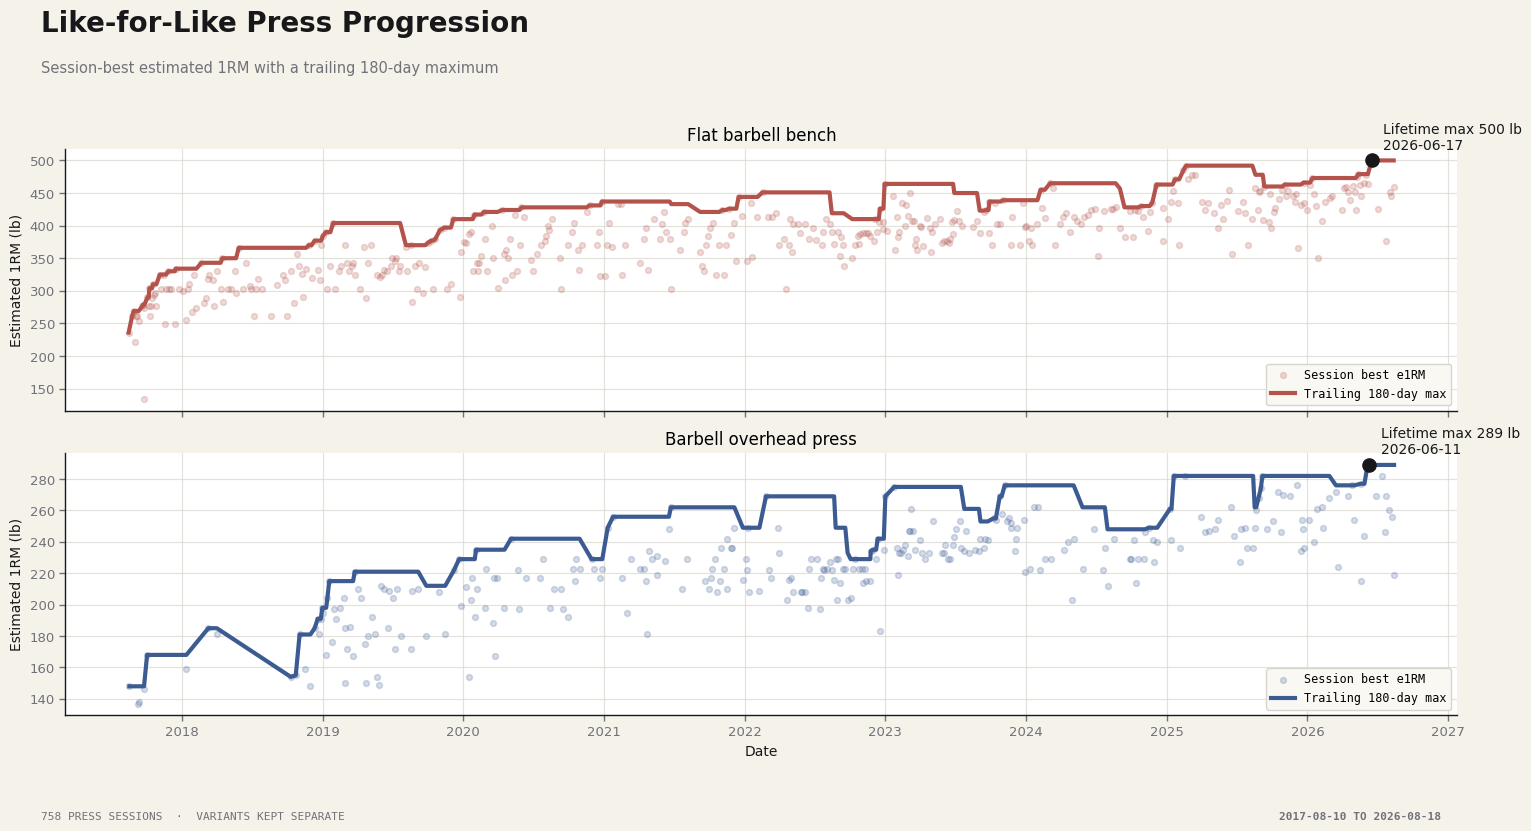

In [13]:
frame = notebook_frame((16, 9))
with chart_canvas(frame) as (fig, seed_ax):
    fig.delaxes(seed_ax)
    axes = fig.subplots(2, 1, sharex=True)
    fig.subplots_adjust(hspace=0.16)
    colors = {
        "Flat barbell bench": CATEGORICAL_COLORS[1],
        "Barbell overhead press": CATEGORICAL_COLORS[0],
    }
    add_header(
        fig,
        frame,
        "Like-for-Like Press Progression",
        "Session-best estimated 1RM with a trailing 180-day maximum",
        (),
    )
    for ax, family in zip(
        axes, ["Flat barbell bench", "Barbell overhead press"]
    ):
        family_data = session_press[
            session_press["press_family"] == family
        ].sort_values("date")
        ax.scatter(
            family_data["date"], family_data["best_e1rm"], s=18, alpha=0.22,
            color=colors[family], label="Session best e1RM",
        )
        rolling = (
            family_data.set_index("date")["best_e1rm"]
            .rolling("180D", min_periods=1)
            .max()
        )
        ax.plot(
            rolling.index, rolling, lw=3, color=colors[family],
            label="Trailing 180-day max",
        )
        best = family_data.loc[family_data["best_e1rm"].idxmax()]
        ax.scatter(
            [best["date"]], [best["best_e1rm"]], s=90,
            color=PALETTE.ink, zorder=5,
        )
        ax.annotate(
            f"Lifetime max {best['best_e1rm']:.0f} lb\n{best['date']:%Y-%m-%d}",
            (best["date"], best["best_e1rm"]),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=10,
            color=PALETTE.ink,
        )
        ax.set(title=family, ylabel="Estimated 1RM (lb)")
        style_axes(ax, NOTEBOOK_AXES)
        style_legend(ax, loc="lower right")
    axes[-1].set_xlabel("Date")
    add_footer(
        fig,
        frame,
        f"{len(session_press):,} PRESS SESSIONS  ·  VARIANTS KEPT SEPARATE",
        f"{first.date()} TO {latest.date()}",
    )
    fig.savefig(
        OUTPUTS / "press-progression-full-history.png",
        dpi=180,
        facecolor=fig.get_facecolor(),
    )
    plt.show()


In [14]:
def press_period_snapshot(frame, family, start, end, label):
    window = frame[(frame["press_family"] == family) & frame["date"].between(start, end)]
    return {"press_family": family, "period": label, "sessions": window["workout_id"].nunique(),
            "sessions_per_week": window["workout_id"].nunique() / 12, "best_e1rm": window["best_e1rm"].max(),
            "median_top5_e1rm": window.nlargest(min(5, len(window)), "best_e1rm")["best_e1rm"].median() if len(window) else np.nan}

press_recent_compare = pd.DataFrame([
    press_period_snapshot(session_press, family, start, end, label)
    for family in ["Flat barbell bench", "Barbell overhead press"]
    for start, end, label in [(prior_start, prior_end, "Prior 12 weeks"), (current_start, latest, "Current 12 weeks")]
])
press_recent_compare.to_csv(OUTPUTS / "press-current-vs-prior.csv", index=False)
press_recent_compare


,press_family,period,sessions,sessions_per_week,best_e1rm,median_top5_e1rm
0,Flat barbell bench,Prior 12 weeks,13,1.083333,479.0,463.0
1,Flat barbell bench,Current 12 weeks,9,0.750000,500.0,466.0
2,Barbell overhead press,Prior 12 weeks,7,0.583333,277.0,272.0
3,Barbell overhead press,Current 12 weeks,10,0.833333,289.0,282.0


## 5. Exercise concentration and audit tables

In [15]:
exercise_current = (
    current.groupby(["name", "iteration", "category"], as_index=False)
    .agg(sets=("set_id", "nunique"), sessions=("workout_id", "nunique"), latest=("date", "max"))
    .assign(sets_per_week=lambda x: x["sets"] / 12).sort_values("sets", ascending=False)
)
exercise_current.to_csv(OUTPUTS / "exercise-volume-current-12w.csv", index=False)
exercise_current.head(40)


,name,iteration,category,sets,sessions,latest,sets_per_week
30,Lateral Raises,Dumbbell,Shoulders,113,23,2026-08-17 00:00:00+00:00,9.416667
19,Hammer Curls,Dumbbell,Biceps,91,21,2026-08-10 00:00:00+00:00,7.583333
15,Deadlifts,Conventional,Legs,50,9,2026-08-15 00:00:00+00:00,4.166667
5,Barbell Bench Press,Flat,Chest,45,9,2026-08-13 00:00:00+00:00,3.750000
69,Weighted Crunches,Cable,Abs / Core,43,12,2026-08-16 00:00:00+00:00,3.583333
49,Overhead Press,Barbell,Shoulders,42,10,2026-08-14 00:00:00+00:00,3.500000
62,Squats,Back,Legs,34,6,2026-07-19 00:00:00+00:00,2.833333
52,Preacher Curls,Barbell,Biceps,31,7,2026-08-18 00:00:00+00:00,2.583333
0,Ab Roller,Knees,Abs / Core,31,8,2026-08-16 00:00:00+00:00,2.583333
65,Tricep Pushdowns,Two-arm,Triceps,31,8,2026-08-06 00:00:00+00:00,2.583333


In [16]:
summary_tables = {
    "coverage": coverage, "annual": annual, "period_summary": period_summary,
    "category_compare": category_compare, "stimulus_summary": stimulus_summary,
    "frequency": frequency, "archetypes": archetypes.reset_index(),
    "recent_sequence": recent_sequence, "press_recent_compare": press_recent_compare,
    "press_yearly": press_yearly, "top_exercises": exercise_current.head(40),
}
for summary_name, table in summary_tables.items():
    table.to_csv(OUTPUTS / f"program-analysis-{summary_name}.csv", index=False)
print(f"Wrote {len(summary_tables)} audit tables and 3 chart files to {OUTPUTS}")


Wrote 11 audit tables and 3 chart files to /Users/chappyasel/Desktop/Repos/WeightliftingApp-AnalyzeData/outputs


## 6. Recommendation

The recommendation is maintained in the companion report after reviewing these executed
tables and rendered charts. This keeps the judgment layer explicit rather than burying it
inside plotting code.